# Churn Prediction Model

Binary classification of customer churn on a synthetic subscription-retail customer dataset, comparing
a **Logistic Regression** interpretable baseline against a **Random Forest**, with EDA, ROC-AUC/confusion
matrix evaluation, and feature importance.

See [`docs/design.md`](../docs/design.md) for the full problem statement, ER/flow diagram, data
dictionary, and schema design rationale. See [`MODEL_CARD.md`](../MODEL_CARD.md) for intended use,
metrics, and limitations.

**Skills demonstrated:** Python, pandas, EDA, scikit-learn (Logistic Regression, Random Forest),
classification evaluation (ROC-AUC, precision/recall, confusion matrix), feature importance, model
documentation.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from src.data_generation import generate_customers
from src.features import build_feature_matrix, scale_numeric, NUMERIC_COLUMNS
from src.models import fit_logistic_regression, fit_random_forest
from src.evaluation import evaluate_model, get_roc_points, get_confusion_matrix

pd.set_option("display.max_columns", 50)
plt.rcParams["figure.figsize"] = (7, 5)

## 1. Generate synthetic data

See `src/data_generation.py` — churn probability is driven by contract type, tenure, support tickets, usage, payment method, plus noise.

In [2]:
raw = generate_customers(n=5000, seed=7)
print(raw.shape, "| churn rate:", round(raw['churned'].mean(), 3))
raw.head()

(5000, 11) | churn rate: 0.149


,customer_id,tenure_months,contract_type,payment_method,monthly_charges,total_charges,num_support_tickets,avg_monthly_usage,has_addon_service,auto_pay_enabled,churned
0,CUST_000001,69,one-year,credit-card,94.91,6756.29,1,88.3,False,False,False
1,CUST_000002,46,one-year,e-check,68.20,3180.13,0,56.7,False,True,True
2,CUST_000003,50,one-year,credit-card,84.16,4151.60,0,67.2,True,False,False
3,CUST_000004,65,month-to-month,e-check,70.91,4494.30,1,62.0,False,False,False
4,CUST_000005,42,month-to-month,e-check,67.38,2761.42,2,100.0,False,True,False


## 2. Exploratory data analysis

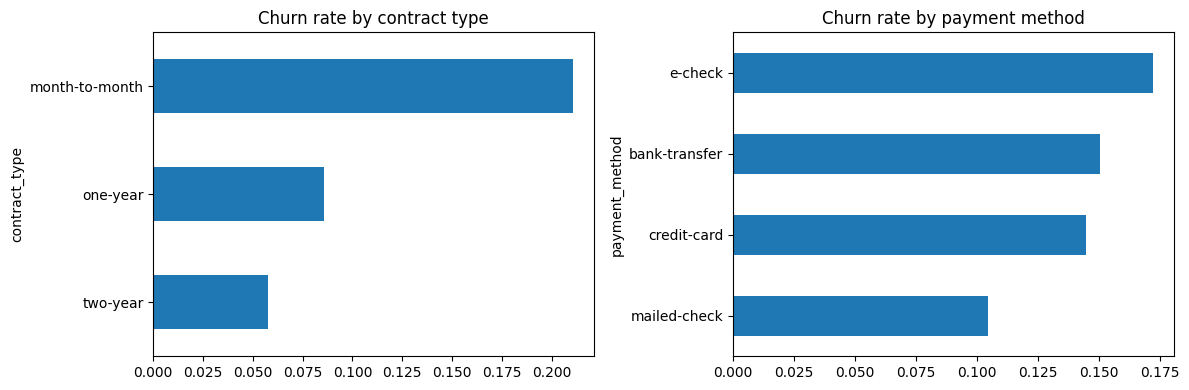

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
raw.groupby("contract_type")["churned"].mean().sort_values().plot.barh(ax=axes[0], title="Churn rate by contract type")
raw.groupby("payment_method")["churned"].mean().sort_values().plot.barh(ax=axes[1], title="Churn rate by payment method")
plt.tight_layout()
plt.savefig("../outputs/churn_rate_by_category.png", dpi=110)
plt.show()

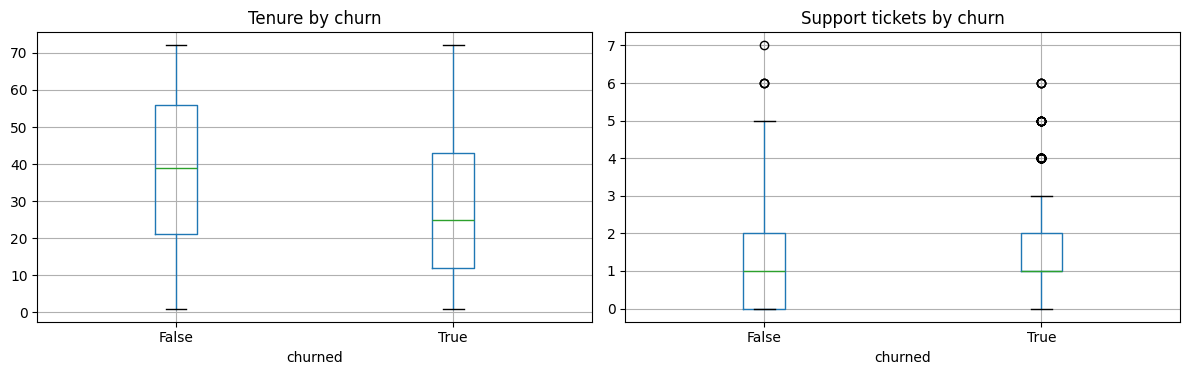

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
raw.boxplot(column="tenure_months", by="churned", ax=axes[0])
axes[0].set_title("Tenure by churn"); axes[0].set_xlabel("churned")
raw.boxplot(column="num_support_tickets", by="churned", ax=axes[1])
axes[1].set_title("Support tickets by churn"); axes[1].set_xlabel("churned")
plt.suptitle("")
plt.tight_layout()
plt.savefig("../outputs/eda_boxplots.png", dpi=110)
plt.show()

## 3. Feature preparation

One-hot encode categoricals, split train/test (stratified on the label since churn is imbalanced), then scale numeric columns for Logistic Regression.

In [5]:
X, y = build_feature_matrix(raw)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
X_train_scaled, X_test_scaled, scaler = scale_numeric(X_train, X_test)
print(f"train: {X_train.shape}, test: {X_test.shape}, train churn rate: {y_train.mean():.3f}")

train: (3750, 14), test: (1250, 14), train churn rate: 0.149


## 4. Train models

In [6]:
logreg = fit_logistic_regression(X_train_scaled, y_train)
rf = fit_random_forest(X_train, y_train)  # tree models don't need scaling

logreg_proba = logreg.predict_proba(X_test_scaled)[:, 1]
rf_proba = rf.predict_proba(X_test)[:, 1]

logreg_pred = (logreg_proba >= 0.5).astype(int)
rf_pred = (rf_proba >= 0.5).astype(int)

## 5. Evaluation: ROC-AUC, precision/recall, confusion matrices

In [7]:
results = pd.DataFrame({
    "Logistic Regression": evaluate_model(y_test, logreg_pred, logreg_proba),
    "Random Forest": evaluate_model(y_test, rf_pred, rf_proba),
}).T.round(3)
results.to_csv("../outputs/model_comparison.csv")
results

,roc_auc,precision,recall,f1
Logistic Regression,0.768,0.284,0.715,0.406
Random Forest,0.748,0.306,0.570,0.398


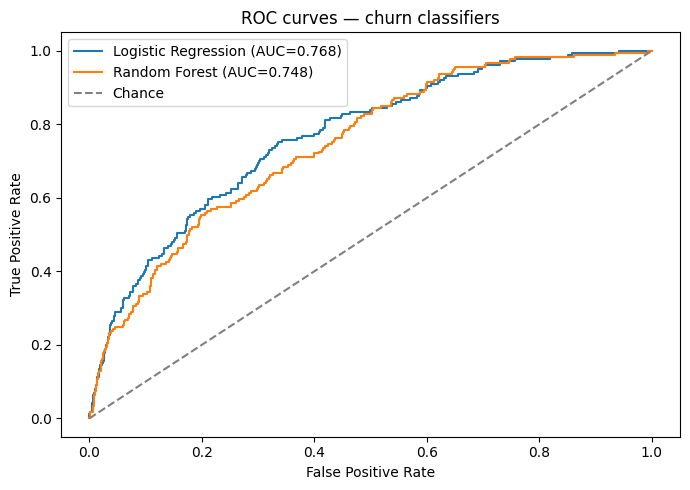

In [8]:
fig, ax = plt.subplots()
for name, proba in [("Logistic Regression", logreg_proba), ("Random Forest", rf_proba)]:
    fpr, tpr = get_roc_points(y_test, proba)
    auc = results.loc[name, "roc_auc"]
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Chance")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC curves — churn classifiers")
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/roc_curve.png", dpi=110)
plt.show()

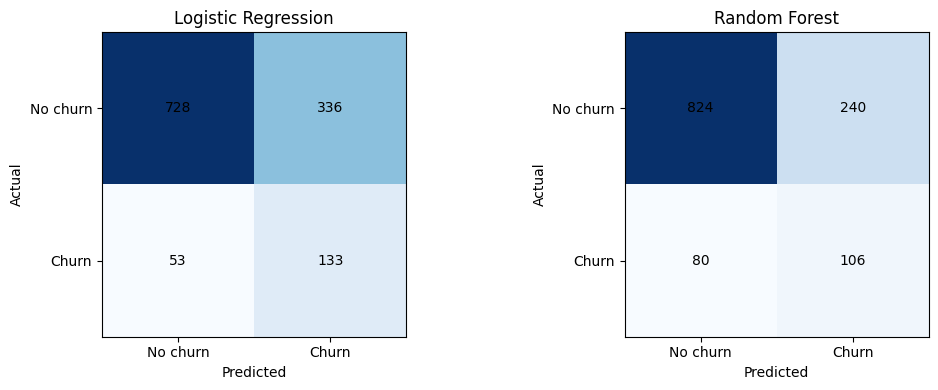

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (name, pred) in zip(axes, [("Logistic Regression", logreg_pred), ("Random Forest", rf_pred)]):
    cm = get_confusion_matrix(y_test, pred)
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(name)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["No churn", "Churn"]); ax.set_yticklabels(["No churn", "Churn"])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center", color="black")
plt.tight_layout()
plt.savefig("../outputs/confusion_matrix.png", dpi=110)
plt.show()

## 6. Feature importance

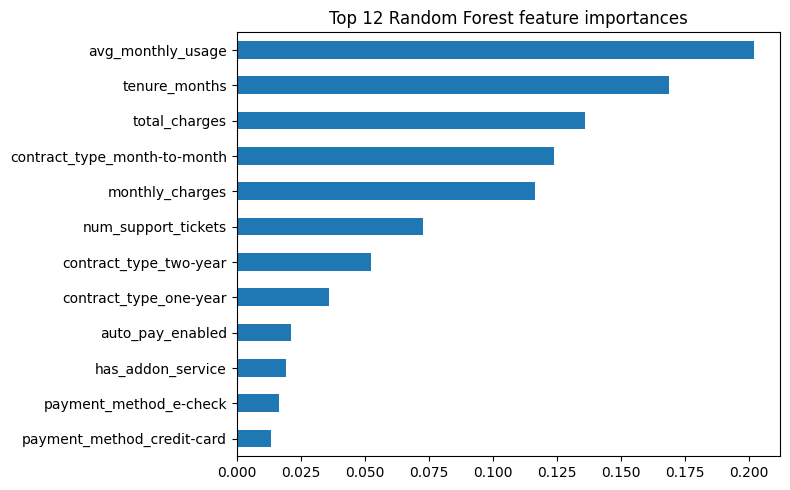

In [10]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(12)
fig, ax = plt.subplots(figsize=(8, 5))
importances.iloc[::-1].plot.barh(ax=ax)
ax.set_title("Top 12 Random Forest feature importances")
plt.tight_layout()
plt.savefig("../outputs/feature_importance.png", dpi=110)
plt.show()

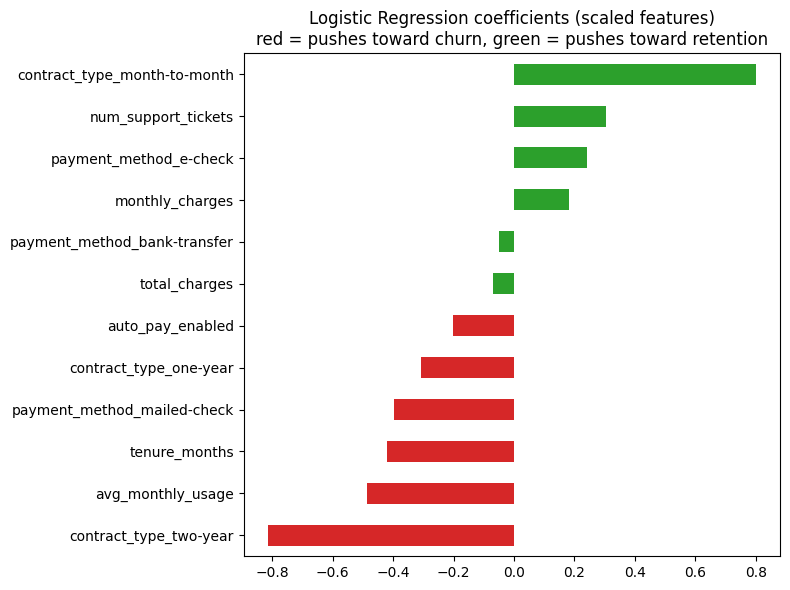

In [11]:
coefs = pd.Series(logreg.coef_[0], index=X.columns).sort_values()
fig, ax = plt.subplots(figsize=(8, 6))
pd.concat([coefs.head(6), coefs.tail(6)]).plot.barh(ax=ax, color=["#d62728"]*6 + ["#2ca02c"]*6)
ax.set_title("Logistic Regression coefficients (scaled features)\nred = pushes toward churn, green = pushes toward retention")
plt.tight_layout()
plt.savefig("../outputs/logreg_coefficients.png", dpi=110)
plt.show()

## 7. Business recommendations

- **Contract type dominates:** month-to-month customers churn far more than one/two-year contract
  customers in both the raw churn-rate breakdown and the model's feature importances/coefficients.
  Incentivizing term-contract upgrades is the single highest-leverage retention lever here.
- **Support tickets and low usage are early-warning signals:** customers with 2+ recent support tickets
  and below-median usage show materially elevated churn probability — a natural trigger for a proactive
  retention outreach rule, independent of the full model.
- **Random Forest vs Logistic Regression:** compare the ROC-AUC row above — if the Random Forest's gain
  over the linear baseline is small, prefer the Logistic Regression in production for its interpretability
  (each coefficient has a direct "this factor moves churn odds by X" explanation retention agents can use
  in conversation).
- See `MODEL_CARD.md` for intended use, evaluation data, and limitations before using this for real
  decisions.